In [1]:
from pathlib import Path
import json
import pandas as pd

import cv2
import numpy as np
import torch
from ultralytics import YOLOE
from ultralytics.models.yolo.yoloe import YOLOEVPSegPredictor

import matplotlib.pyplot as plt

from tqdm.auto import tqdm
tqdm.pandas()

In [2]:
def load_reference(ref_json_path: str):
    with open(ref_json_path, "r") as f:
        data = json.load(f)
    if isinstance(data, list):
        data = data[0]  # une seule référence pour ce premier test
    boxes = np.array(data["boxes"], dtype=np.float32)
    return data["image"], boxes

In [6]:
PROJECT_ROOT = Path.cwd().parent
LOGS_PATH = PROJECT_ROOT / 'logs' / 'wing_extraction_log.csv'
REFERENCE_PATH = PROJECT_ROOT / 'data' / 'references' / 'ref.json'

INPUT_DIR = PROJECT_ROOT / 'data' / 'images' / 'organized'
OUTPUT_DIR = PROJECT_ROOT / 'out' / 'predicted_crops'

wing_crops = pd.read_csv(LOGS_PATH)
wing_crops = wing_crops.loc[wing_crops.status == 'OK']

In [5]:
wing_crops.head()

,name,image,status,n_detections,confidence,obb,aspect,similarity,output
0,FR15_ABOM07082020038_P1,Bombus_confusus\male\FR15_ABOM07082020038_P1.JPG,OK,4,0.772,"[[3044.8, 1980.7], [1933.3, 1980.7], [1933.2, ...",2.36,0.940,data\images\wing_crops\Bombus_confusus\male\FR...
1,FR15_ABOM07082020038_P2,Bombus_confusus\male\FR15_ABOM07082020038_P2.JPG,OK,2,0.884,"[[3040.0, 2037.8], [1928.5, 2037.8], [1928.5, ...",2.46,0.911,data\images\wing_crops\Bombus_confusus\male\FR...
2,FR15_ABOM07082020038_S1,Bombus_confusus\male\FR15_ABOM07082020038_S1.jpg,OK,2,0.860,"[[1720.7, 2098.7], [637.9, 2098.7], [637.9, 16...",2.39,0.900,data\images\wing_crops\Bombus_confusus\male\FR...
3,FR15_ABOM07082020038_S2,Bombus_confusus\male\FR15_ABOM07082020038_S2.jpg,OK,2,0.809,"[[1578.9, 2145.9], [511.9, 2145.9], [511.9, 16...",2.36,0.923,data\images\wing_crops\Bombus_confusus\male\FR...
4,FR15_ABOM07082020038_S3,Bombus_confusus\male\FR15_ABOM07082020038_S3.jpg,OK,2,0.868,"[[1626.2, 2098.7], [606.4, 2098.7], [606.4, 16...",2.33,0.897,data\images\wing_crops\Bombus_confusus\male\FR...


In [8]:
# target = PROJECT_ROOT / usables.iloc[232].chemin_wide
idxs = [0, 10, 100, 232, 980, 1000, 1001, 1295, 1536, 2016]

target_images = [str(INPUT_DIR / wing_crops.iloc[idx].image) for idx in idxs]

ref_image, boxes = load_reference(REFERENCE_PATH)
n_boxes = len(boxes)
print(f"Reference : {ref_image}  ({n_boxes} box(es))")
print(f"Targets   : {target_images}")

visual_prompts = dict(
    bboxes=boxes,
    cls=np.zeros(n_boxes, dtype=int),  # une seule classe "aile" -> id 0
)

Reference : c:\Users\Jules\Documents\IEES\idmybee\data\images\organized\Bombus_confusus\male\FR15_ABOM07082020038_P1.JPG  (1 box(es))
Targets   : ['c:\\Users\\Jules\\Documents\\IEES\\idmybee\\data\\images\\organized\\Bombus_confusus\\male\\FR15_ABOM07082020038_P1.JPG', 'c:\\Users\\Jules\\Documents\\IEES\\idmybee\\data\\images\\organized\\Bombus_confusus\\male\\FR15_ABOM080820007_P1.JPG', 'c:\\Users\\Jules\\Documents\\IEES\\idmybee\\data\\images\\organized\\Bombus_confusus\\queen\\FR15ABOM060621003_P1.JPG', 'c:\\Users\\Jules\\Documents\\IEES\\idmybee\\data\\images\\organized\\Bombus_lapidarius\\male\\OPIE_Lapi_100820_S1.jpg', 'c:\\Users\\Jules\\Documents\\IEES\\idmybee\\data\\images\\organized\\Bombus_pratorum\\male\\POLLINIS4351_S2.jpg', 'c:\\Users\\Jules\\Documents\\IEES\\idmybee\\data\\images\\organized\\Bombus_pratorum\\queen\\ABAURA5103_S2.jpg', 'c:\\Users\\Jules\\Documents\\IEES\\idmybee\\data\\images\\organized\\Bombus_pratorum\\queen\\ABAURA5103_S3.jpg', 'c:\\Users\\Jules\\Docum

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = YOLOE("../data/models/yoloe-11s-seg.pt")

results = model.predict(
    target_images,
    refer_image=ref_image,
    visual_prompts=visual_prompts,
    predictor=YOLOEVPSegPredictor,
    conf=0.05,
    imgsz=1024,
    device=device,
    verbose=False,
)

1 détection(s) sur l'image cible :
  [0] bbox=[1873.3, 1515.7, 3044.6, 1971.0]  conf=0.826
1 détection(s) sur l'image cible :
  [0] bbox=[1798.1, 1497.2, 3196.9, 2057.1]  conf=0.839
1 détection(s) sur l'image cible :
  [0] bbox=[1657.7, 1436.1, 3165.5, 2145.5]  conf=0.799
2 détection(s) sur l'image cible :
  [0] bbox=[859.3, 1674.9, 1910.6, 2102.6]  conf=0.564
  [1] bbox=[1537.5, 0.0, 2785.6, 226.3]  conf=0.160
1 détection(s) sur l'image cible :
  [0] bbox=[891.3, 1916.2, 1572.8, 2227.9]  conf=0.096
3 détection(s) sur l'image cible :
  [0] bbox=[679.3, 1659.5, 1628.4, 2240.7]  conf=0.672
  [1] bbox=[1282.0, 0.0, 2589.9, 290.6]  conf=0.165
  [2] bbox=[327.5, 3397.8, 2495.3, 4031.7]  conf=0.156
3 détection(s) sur l'image cible :
  [0] bbox=[764.9, 1653.5, 1702.8, 2231.7]  conf=0.568
  [1] bbox=[427.3, 3378.5, 2583.0, 4031.6]  conf=0.225
  [2] bbox=[1415.8, 0.0, 2672.8, 297.4]  conf=0.113
2 détection(s) sur l'image cible :
  [0] bbox=[918.0, 1683.3, 1935.3, 2103.3]  conf=0.587
  [1] bbox=

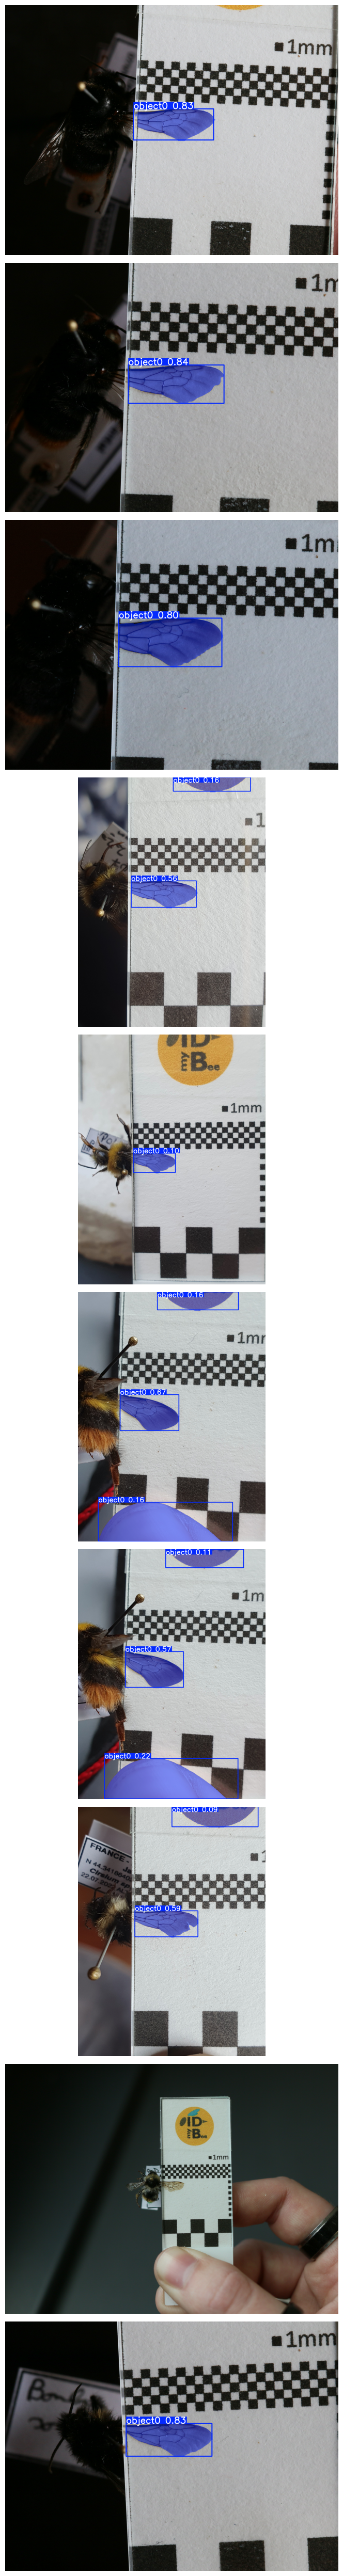

In [11]:
fig, axes = plt.subplots(len(results), 1, figsize=(7, 5*len(results)))

for idx, r in enumerate(results):
    n_det = len(r.boxes) if r.boxes is not None else 0
    print(f"{n_det} détection(s) sur l'image cible :")
    for i in range(n_det):
        xyxy = r.boxes.xyxy[i].tolist()
        conf = float(r.boxes.conf[i])
        print(f"  [{i}] bbox={[round(v, 1) for v in xyxy]}  conf={conf:.3f}")

    annotated_img = r.plot()
    cv2.resize(annotated_img, None, fx=0.5, fy=0.5)
    axes[idx].imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('result.png', dpi=150)
plt.show()